In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [4]:
df = pd.read_csv("../data/winequality-red.csv", sep=";")

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
df.shape

(1599, 12)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


各自trait的解釋如下: <br>
   1 - fixed acidity 固定酸(非揮發性): most acids involved with wine or fixed or nonvolatile (do not evaporate readily) <br>
   2 - volatile acidity 揮發性酸 : the amount of acetic acid (乙酸) in wine, which at too high of levels can lead to an unpleasant, vinegar taste <br>
   3 - citric acid 檸檬酸 : found in small quantities, citric acid can add 'freshness' and flavor to wines <br>
   4 - residual sugar 殘糖 :  the amount of sugar remaining after fermentation stops, it's rare to find wines with less than 1 gram/liter and wines with greater than 45 grams/liter are considered sweet <br>
   5 - chlorides 氯化物 : the amount of salt in the wine <br>
   6 - free sulfur dioxide 遊離二氧化硫 : the free form of SO2 exists in equilibrium between molecular SO2 (as a dissolved gas) and bisulfite ion; it prevents microbial growth and the oxidation of wine <br>
   7 - total sulfur dioxide 總二氧化硫 :  amount of free and bound forms of S02; in low concentrations, SO2 is mostly undetectable in wine, but at free SO2 concentrations over 50 ppm, SO2 becomes evident in the nose and taste of wine <br>
   8 - density 密度 : the density of water is close to that of water depending on the percent alcohol and sugar conten <br>
   9 - pH : describes how acidic or basic a wine is on a scale from 0 (very acidic) to 14 (very basic); most wines are between 3-4 on the pH scale
 <br>
   10 - sulphates 硫酸鹽 : a wine additive which can contribute to sulfur dioxide gas (S02) levels, wich acts as an antimicrobial and antioxidant <br>
   11 - alcohol <br>


In [7]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [8]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

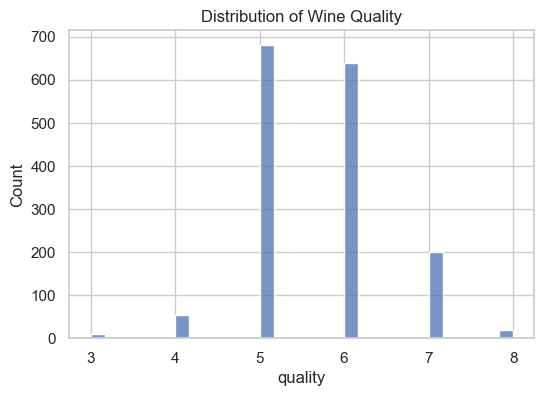

In [11]:
plt.figure(figsize=(6,4))
sns.histplot(df["quality"])

plt.title("Distribution of Wine Quality")
plt.show()

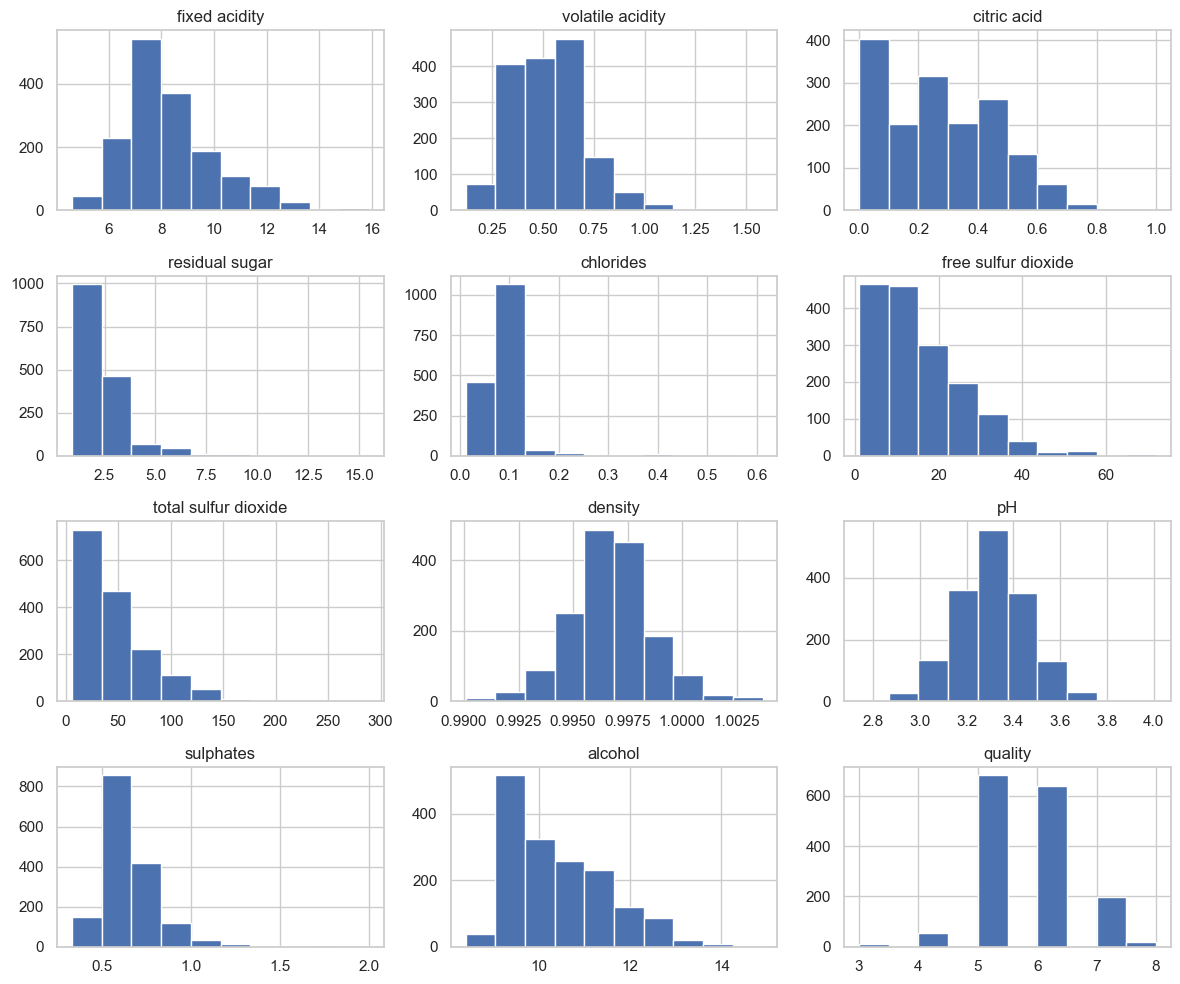

In [12]:
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

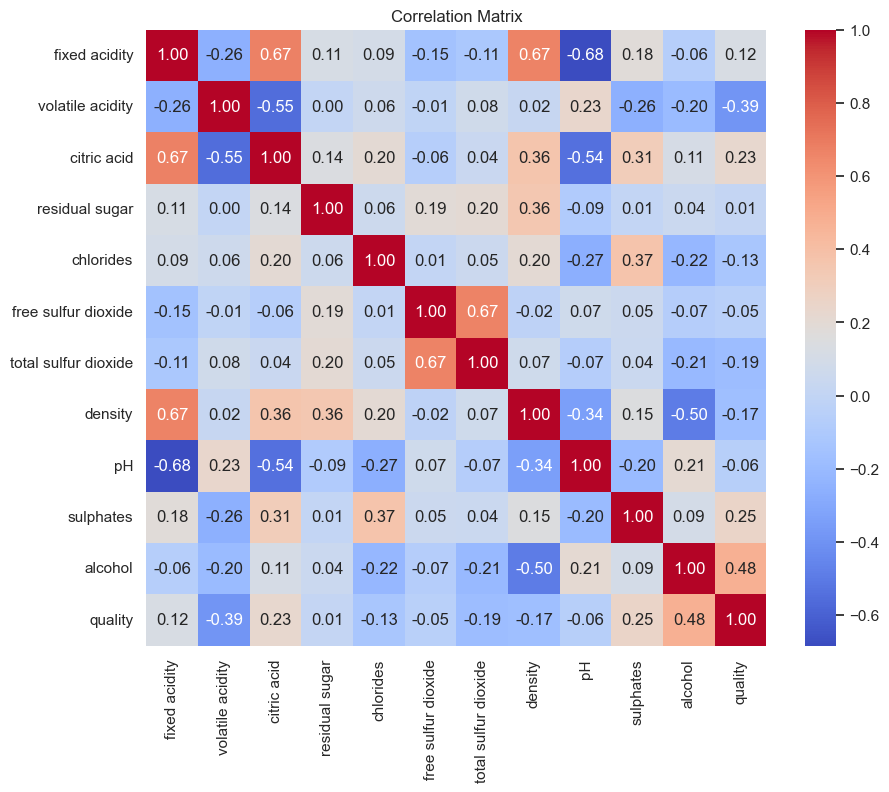

In [13]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

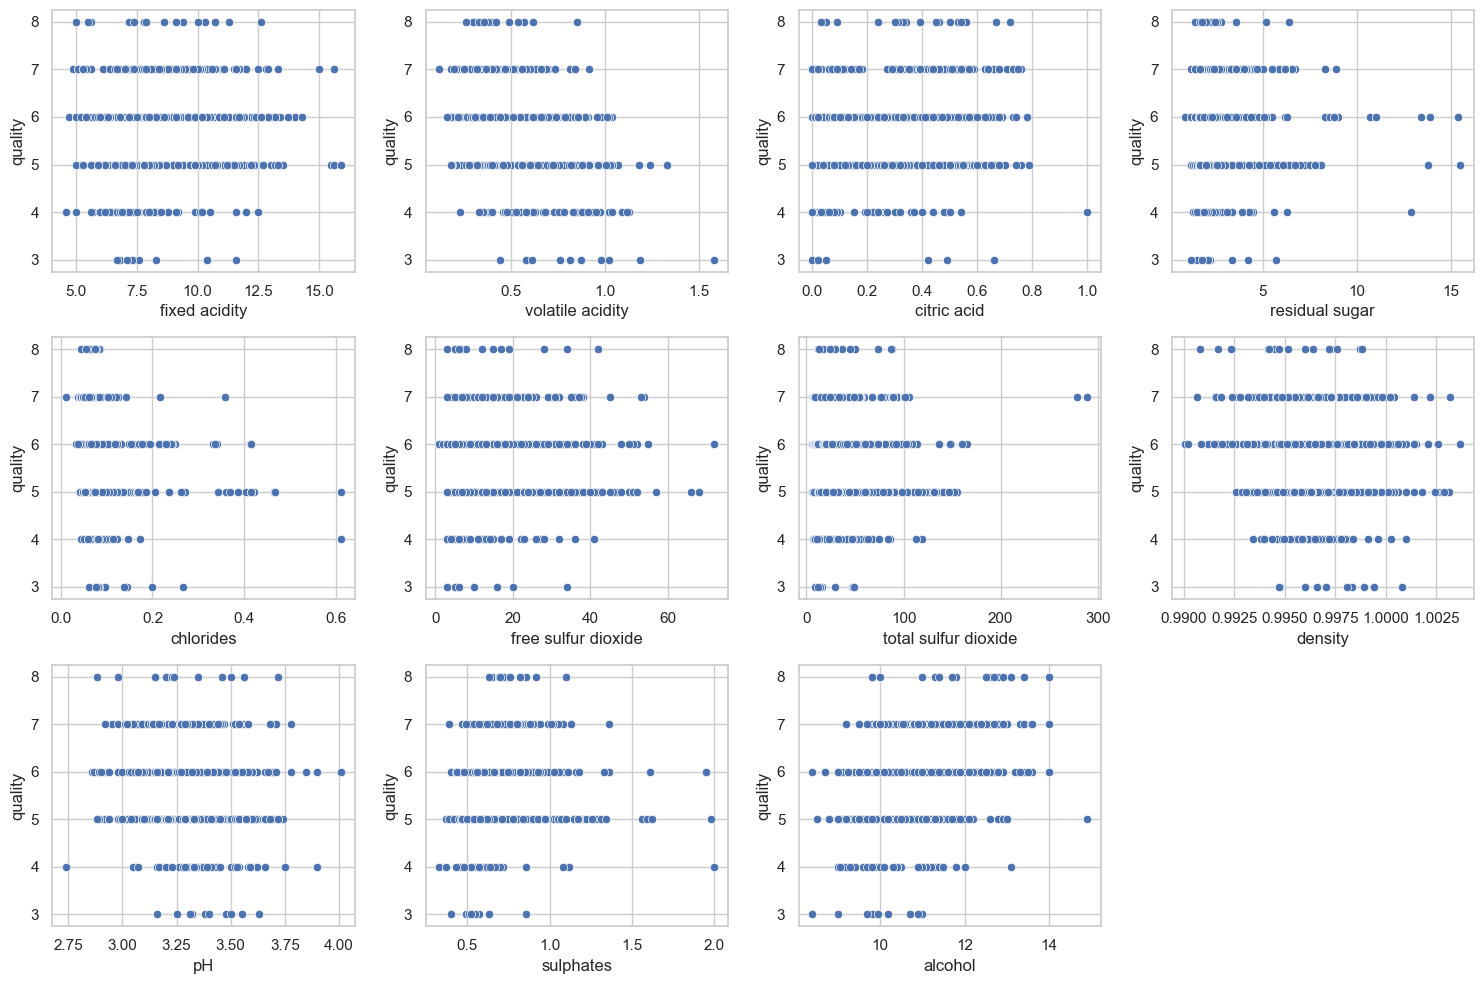

In [14]:
features = df.columns.drop("quality")

plt.figure(figsize=(15,10))

for i, col in enumerate(features):
    
    plt.subplot(3,4,i+1)
    
    sns.scatterplot(
        x=df[col],
        y=df["quality"]
    )

plt.tight_layout()
plt.show()

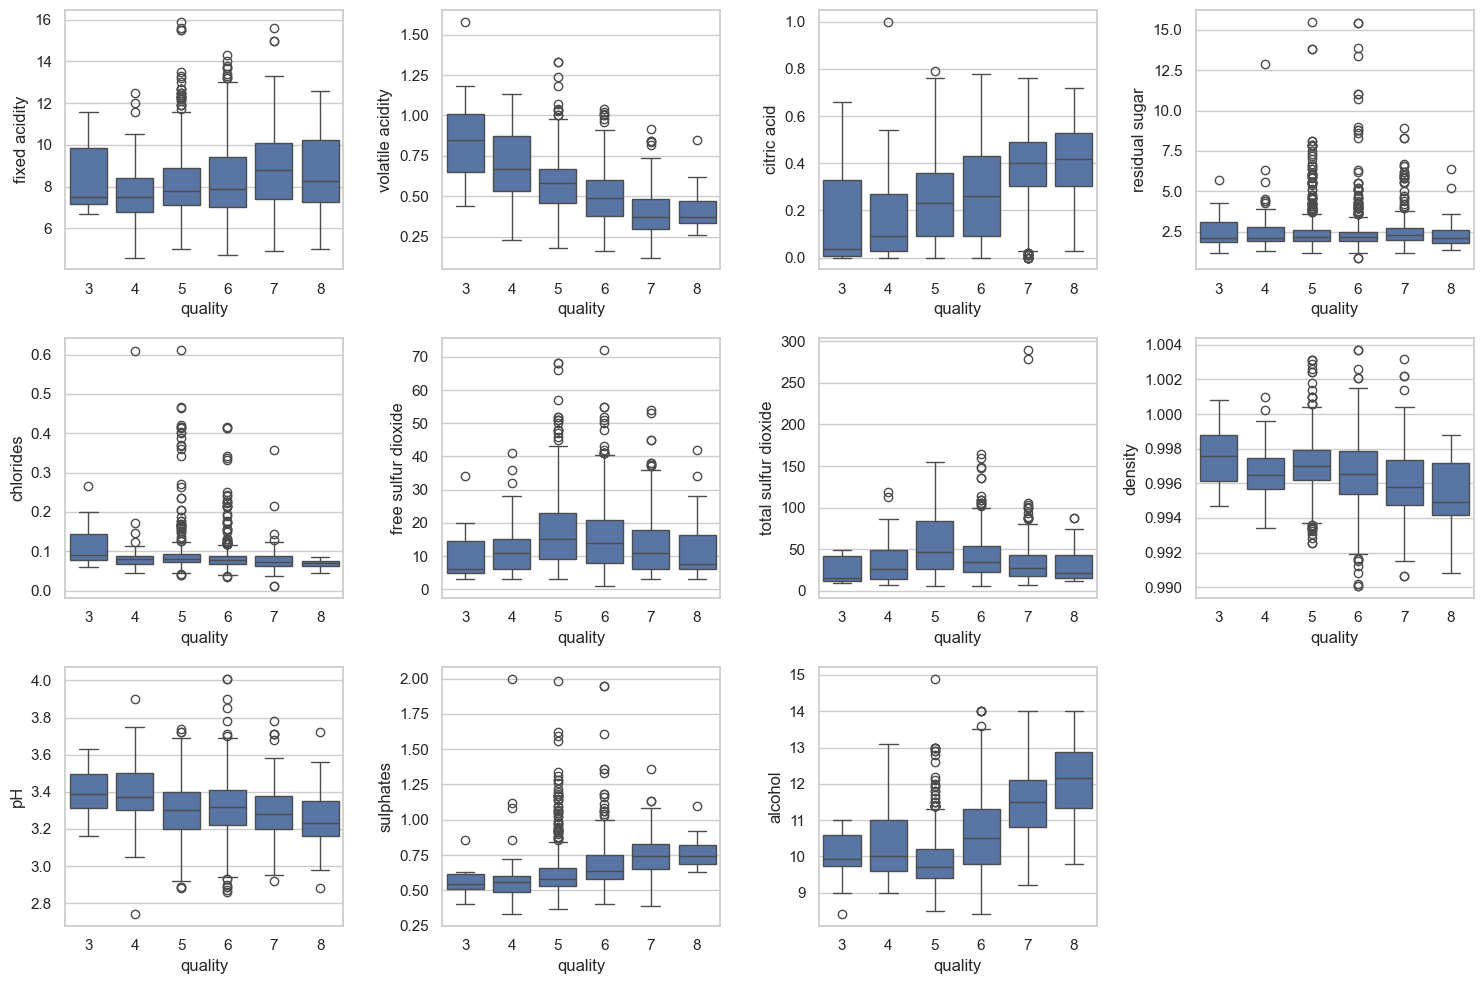

In [15]:
plt.figure(figsize=(15,10))

for i, col in enumerate(features):
    
    plt.subplot(3,4,i+1)
    
    sns.boxplot(
        x=df["quality"],
        y=df[col]
    )

plt.tight_layout()
plt.show()

Summary <br>
由以上的初步探勘， 我們可以得知這筆資料一共有1590個sample並且有12個trait，全部並無缺值，其中我們想找出quality與其他個性狀之間是否有相關? 
1. 可以從quality的分布可知大多分數在5與6分。
2. 而從其他trait的分布來看某些分布有些偏移，可能不是常態分佈。
3. 最主要的相關性我們可以發現quailty與Alcohol content呈現中度正相關；與Volatile acid呈現中度負相關，其餘性狀皆為低相關性。
4. 性狀之間，固定酸與檸檬酸、密度呈現高度正相關與pH值呈現高度負相關，其中檸檬酸又與游離酸呈現中度負相關； 遊離二氧化硫則與總二氧化硫呈現高度正相關。